In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/climaDS.csv.gz')
df

,year,month,day,country_id,country,capital,latitude,longitude,wind_kph,precip_mm,humidity,cloud,Air_poll,sun_h,temp_C
0,2024,5,16,0,Afghanistan,Kabul,34.52,69.18,13.3,0.0,24,30,1,14.00,26.6
1,2024,5,16,1,Albania,Tirana,41.33,19.82,11.2,0.1,94,75,1,14.55,19.0
2,2024,5,16,2,Algeria,Algiers,36.76,3.05,15.1,0.0,29,0,1,14.17,23.0
3,2024,5,16,3,Andorra,Andorra La Vella,42.50,1.52,11.9,0.3,61,100,1,14.67,6.3
4,2024,5,16,4,Angola,Luanda,-8.84,13.23,13.0,0.0,89,50,10,11.72,26.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139526,2026,5,5,180,Venezuela,Caracas,10.50,-66.92,7.6,0.0,81,13,1,12.53,17.7
139527,2026,5,5,181,Vietnam,Hanoi,21.03,105.85,9.4,0.0,55,25,10,12.98,30.1
139528,2026,5,5,182,Yemen,Sanaa,15.35,44.21,9.7,0.0,27,2,2,12.73,23.0
139529,2026,5,5,183,Zambia,Lusaka,-15.42,28.28,11.2,0.0,72,17,1,11.52,19.9


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [5]:
features = ['longitude', 'temp_C', 'humidity', 'precip_mm', 'wind_kph', 'cloud', 'Air_poll', 'sun_h'] #Final
# features = ['temp_C', 'humidity', 'precip_mm', 'wind_kph', 'cloud', 'Air_poll', 'sun_h'] #Hard
X = df[features]
y = df['country_id']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
xgb_model = XGBClassifier(
    n_estimators=40, #20, #Final 
    learning_rate=0.2, #0.1, #Final
    max_depth=4, #4, #Final 
    min_child_weight=6,
    use_label_encoder=False,
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1
)

In [7]:
xgb_model.fit(X_train, y_train)

c:\Users\detla\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:07:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [8]:
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"📊 Accuracy en Test: {accuracy:.4f}")

📊 Accuracy en Test: 0.9968


In [9]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df)

              precision    recall  f1-score       support
0              1.000000  1.000000  1.000000    144.000000
1              1.000000  1.000000  1.000000    143.000000
2              1.000000  1.000000  1.000000    143.000000
3              1.000000  1.000000  1.000000    144.000000
4              1.000000  1.000000  1.000000    143.000000
...                 ...       ...       ...           ...
184            1.000000  1.000000  1.000000    143.000000
185            1.000000  1.000000  1.000000     51.000000
accuracy       0.996811  0.996811  0.996811      0.996811
macro avg      0.996706  0.996681  0.996678  27907.000000
weighted avg   0.996833  0.996811  0.996807  27907.000000

[189 rows x 4 columns]


In [10]:
# 3. COMPROBAR OVERFITTING
# Predicción en TRAIN (datos que el modelo YA ha visto)
y_pred_train = xgb_model.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)

# Predicción en TEST (datos NUEVOS que el modelo NO ha visto)
y_pred_test = xgb_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)

print("-" * 30)
print(f"📊 Accuracy en TRAIN: {acc_train:.4f}")
print(f"📊 Accuracy en TEST:  {acc_test:.4f}")
print("-" * 30)

------------------------------
📊 Accuracy en TRAIN: 0.9979
📊 Accuracy en TEST:  0.9968
------------------------------


In [11]:

diff = acc_train - acc_test

if diff > 0.10: # Si la diferencia es mayor al 10%
    print("⚠️ POSIBLE OVERFITTING DETECTADO.")
    print("El modelo funciona mucho mejor con los datos de entrenamiento que con los nuevos.")
    print("Recomendación: Reduce max_depth, aumenta min_child_weight o usa más datos.")
elif diff < 0.02: # Si la diferencia es muy pequeña
    print("✅ BUEN AJUSTE (Good Fit).")
    print("El rendimiento es consistente entre entrenamiento y prueba.")
else:
    print("⚖️ AJUSTE ACCEPTABLE.")
    print("Hay una pequeña brecha, pero es normal en modelos complejos.")


✅ BUEN AJUSTE (Good Fit).
El rendimiento es consistente entre entrenamiento y prueba.


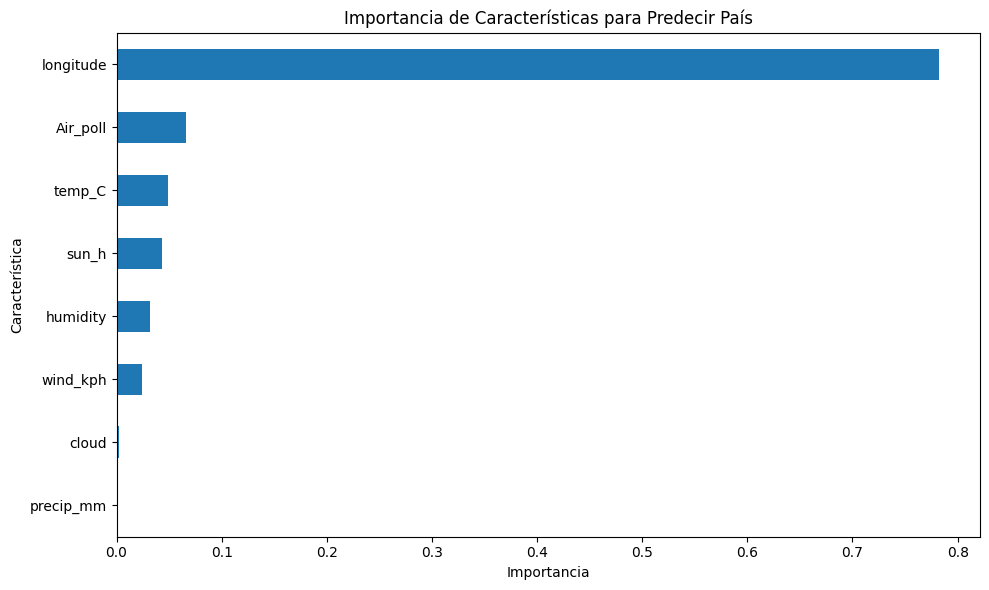

precip_mm    0.000980
cloud        0.002663
wind_kph     0.023932
humidity     0.032234
sun_h        0.042828
temp_C       0.049267
Air_poll     0.065932
longitude    0.782165
dtype: float32


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Asumiendo que 'model' es tu RandomForest ya entrenado y 'feature_cols' tu lista de features
importances = xgb_model.feature_importances_
feat_importances = pd.Series(importances, index=features).sort_values(ascending=True)

# Gráfico de barras horizontal (más limpio para muchas variables)
feat_importances.plot(kind='barh', figsize=(10, 6), title='Importancia de Características para Predecir País')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

print(feat_importances)

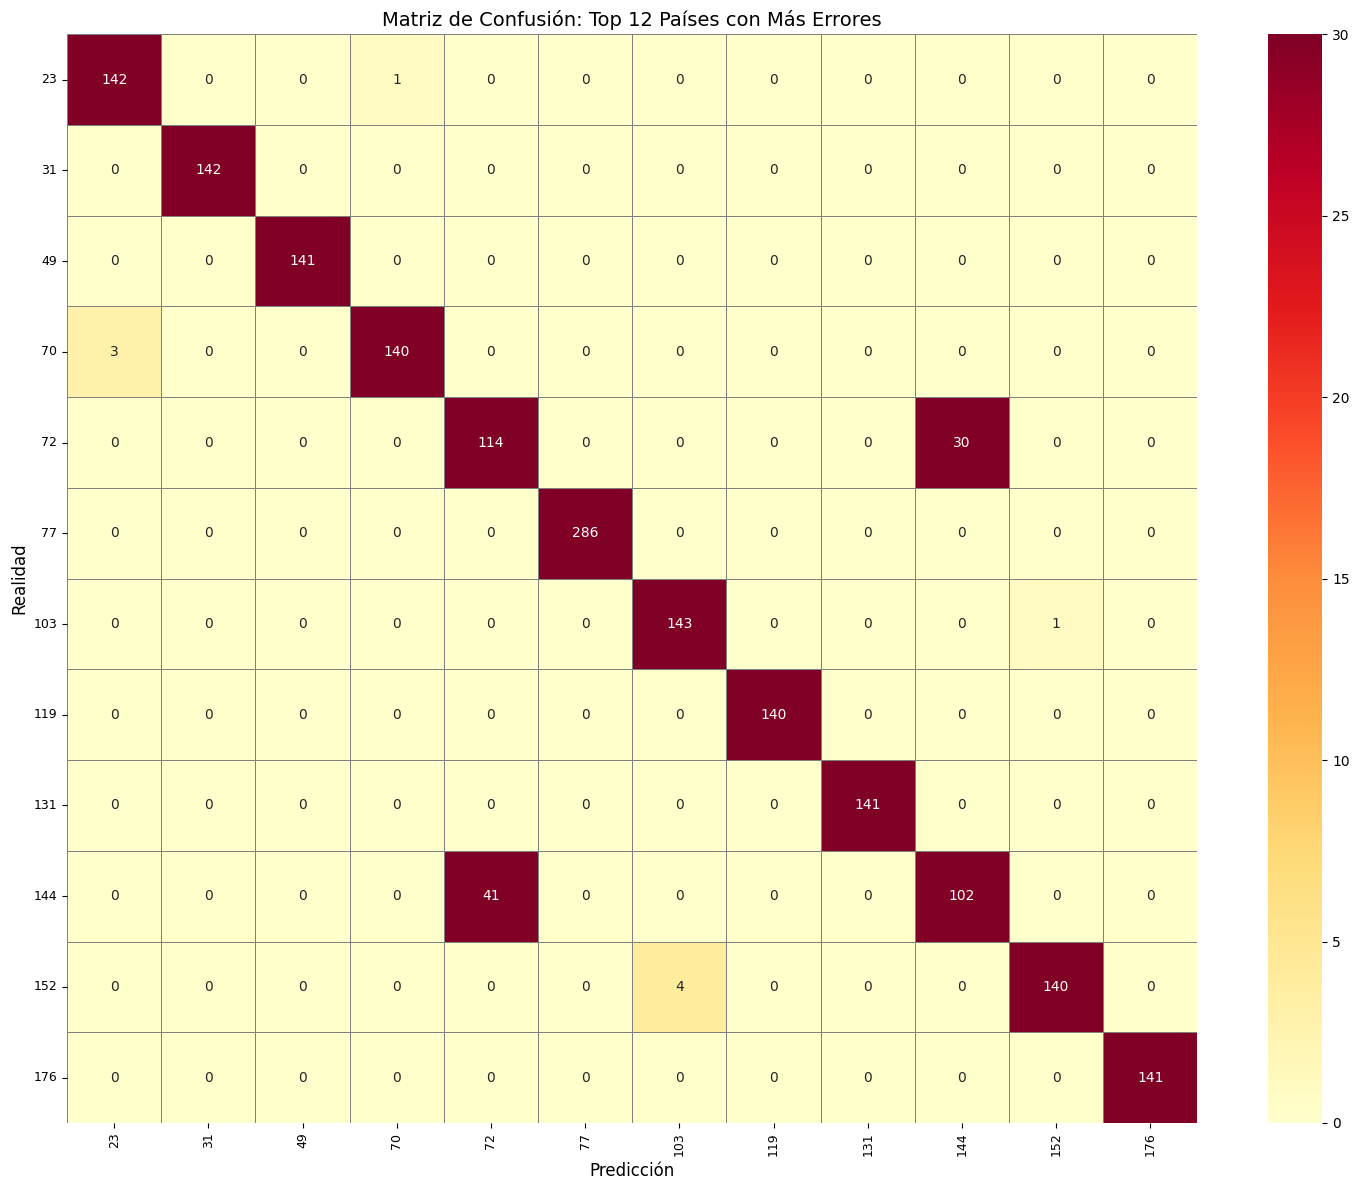

Los 12 países con más errores son:
89
Real
144    41
72     30
152     4
119     3
70      3
131     2
49      1
103     1
31      1
77      1
23      1
176     1
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# 1. Preparar los datos reales y predichos con nombres
y_real_names = y_test
y_pred_names = y_pred

df_results_full = pd.DataFrame({
    'Real': y_real_names,
    'Predicho': y_pred_names
})

# 2. Identificar los 40 países con MÁS ERRORES
# Calculamos errores por país real
errores_por_pais = df_results_full[df_results_full['Real'] != df_results_full['Predicho']]['Real'].value_counts()

# Si hay menos de 40 países con errores, tomamos todos los que tengan errores
n_top = min(40, len(errores_por_pais))
if n_top == 0:
    print("¡El modelo no tuvo ningún error! No hay matriz que mostrar.")
else:
    # Obtenemos los nombres de los países con más errores
    worst_countries = errores_por_pais.head(n_top).index.tolist()
    
    # Ordenamos alfabéticamente para que la matriz sea más legible (opcional, pero recomendado)
    worst_countries_sorted = sorted(worst_countries)

    # --- GRÁFICO: Matriz de Confusión (Top 40 Peores) ---
    plt.figure(figsize=(15, 12))

    # Calculamos la matriz de confusión COMPLETA
    labels_all = np.unique(np.concatenate([y_real_names, y_pred_names]))
    cm_full = confusion_matrix(y_real_names, y_pred_names, labels=labels_all)


    # Obtenemos los índices numéricos originales de los países seleccionados
    indices_worst = [list(labels_all).index(c) for c in worst_countries_sorted]

    # Extraemos la sub-matriz
    cm_subset = cm_full[np.ix_(indices_worst, indices_worst)]

    # Generamos el heatmap
    sns.heatmap(cm_subset, annot=True, fmt='d', cmap='YlOrRd', 
                xticklabels=worst_countries_sorted, yticklabels=worst_countries_sorted,
                linewidths=.5, linecolor='gray',
                vmin=0, vmax=30)
    
    plt.title(f'Matriz de Confusión: Top {n_top} Países con Más Errores', fontsize=14)
    plt.xlabel('Predicción', fontsize=12)
    plt.ylabel('Realidad', fontsize=12)
    plt.xticks(rotation=90, ha='center', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

    # Opcional: Imprimir la lista de estos países para referencia
    print(f"Los {n_top} países con más errores son:")
    print(errores_por_pais.sum())
    print(errores_por_pais.head(n_top))

In [14]:
import joblib

# Nombre del archivo donde se guardará el modelo
filename = '../models/final_boss.pkl'

# Guardar el modelo
joblib.dump(xgb_model, filename)

['../models/final_boss.pkl']